In [1]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt

basePath = '../sims.TNG/TNG100-1/output/'
snap_to_z = np.zeros(100)
for snap in range(100):
    header = il.groupcat.loadHeader(basePath, snap)
    snap_to_z[snap] = header['Redshift']

In [2]:
header = il.groupcat.loadHeader(basePath, 99)
fields_sub = ['SubhaloMass','SubhaloSFRinRad']
subhalos = il.groupcat.loadSubhalos(basePath, 99, fields=fields_sub)

## Total mass of all member particle/cells which are bound to this Subhalo, of all types.
mass_msun = subhalos['SubhaloMass'] * 1e10 / 0.6774  # Total mass of subhalo

## Sum of masses of all particles/cells (split by type) within twice the stellar half mass radius.
mass_type_code = il.groupcat.loadSubhalos(basePath, 99, fields=['SubhaloMassInRadType'])
mass_mstar_msun = mass_type_code[:,4] * 1e10 / 0.6774  ## PartType4 - STARS & WIND PARTICLES

#with np.errstate(invalid='ignore'):
#    ssfr = subhalos['SubhaloSFRinRad'] / mass_mstar_msun

## Index into the Subhalo table of the first (i.e. central/primary) Subfind subhalo within this FoF group. 
GroupFirstSub = il.groupcat.loadHalos(basePath,99,fields=['GroupFirstSub'])
w = np.where(GroupFirstSub >= 0) # value of -1 indicates no subhalo in this group
central_subhalo_ids = GroupFirstSub[w]
print(len(central_subhalo_ids))

3430706


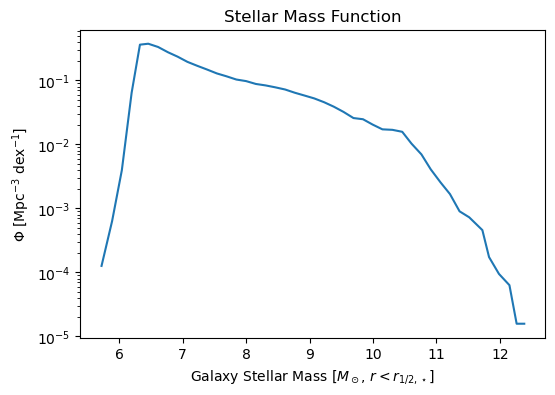

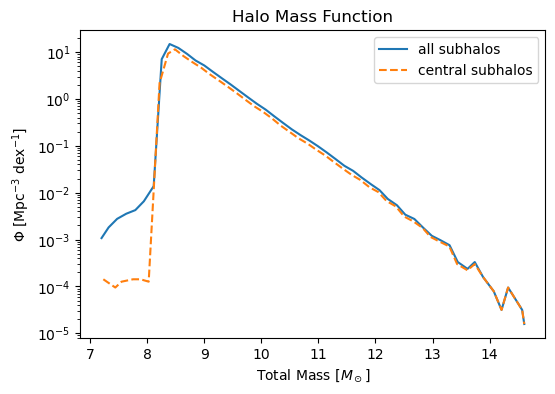

In [3]:
def running_histogram(X, binSize):
    """ Create a adaptive histogram of a (x) point set using some given binsize. """
    minVal = np.nanmin( X[X != 0.0] )

    nBins = int( (np.nanmax(X)-minVal) / binSize )
    bins = np.linspace(minVal,np.nanmax(X), nBins)
    delta = bins[1]-bins[0]

    running_h   = []
    bin_centers = []

    for i, bin in enumerate(bins):
        binMax = bin + delta
        with np.errstate(invalid='ignore'):
            w = np.where((X >= bin) & (X < binMax))

        if len(w[0]):
            running_h.append( len(w[0]) )
            bin_centers.append( np.nanmedian(X[w]) )

    return np.array(bin_centers), np.array(running_h)

binSize = 0.15 # dex

w = np.where(mass_mstar_msun > 0) # only subhalos with nonzero stellar mass
mass_mstar_logmsun = np.log10(mass_mstar_msun[w])

xm, ym = running_histogram(mass_mstar_logmsun, binSize=binSize)

norm_factor = (header['BoxSize']/1000)**3 * binSize

ym = ym / norm_factor

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(xm, ym, '-')
ax.set_yscale('log')
#ax.set_xlim([7.0,12.5])
ax.set_title('Stellar Mass Function')
ax.set_xlabel('Galaxy Stellar Mass [$M_\odot$, $r < r_{\\rm 1/2,\star}$]')
ax.set_ylabel('$\Phi$ [Mpc$^{-3}$ dex$^{-1}$]');

##
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

mass_logmsun = np.log10(mass_msun)
xm, ym = running_histogram(mass_logmsun, binSize=binSize)
norm_factor = (header['BoxSize']/1000)**3 * binSize
ym = ym / norm_factor
ax.plot(xm, ym, '-', label='all subhalos')

mass_logmsun = np.log10(mass_msun[central_subhalo_ids])
xm, ym = running_histogram(mass_logmsun, binSize=binSize)
ym = ym / norm_factor
ax.plot(xm, ym, '--', label='central subhalos')
ax.legend()
ax.set_yscale('log')
#ax.set_xlim([7.0,12.5])
ax.set_title('Halo Mass Function')
ax.set_xlabel('Total Mass [$M_\odot$]')
ax.set_ylabel('$\Phi$ [Mpc$^{-3}$ dex$^{-1}$]');

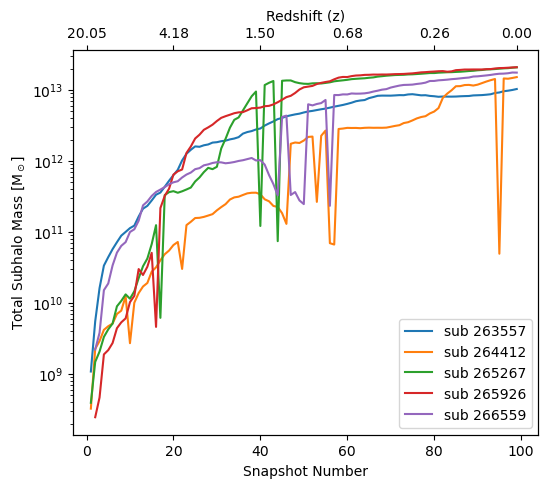

In [4]:
fig = plt.figure(figsize=(6,5)) # 上軸のラベルが見やすくなるよう縦幅を少し広げました
ax = fig.add_subplot(111)

fields = ['SubhaloMass','SubfindID','SnapNum']
start = 99
for i in range(start, start+5):
    tree = il.sublink.loadTree(basePath, 99, central_subhalo_ids[i], fields=fields, onlyMPB=True)
    mass_msun_tree = tree['SubhaloMass'] * 1e10 / 0.6774
    ax.plot(tree['SnapNum'], mass_msun_tree, '-', label='sub %d' % central_subhalo_ids[i])
    
ax.set_yscale('log')
ax.set_xlabel('Snapshot Number')
ax.set_ylabel('Total Subhalo Mass [M$_\odot$]')
ax.legend()

# グラフのX軸の範囲を固定（これを行わないと上下の軸がズレる原因になります）
ax.set_xlim(tree['SnapNum'].min()-5, tree['SnapNum'].max()+5)

# --- 修正版：ここから二重のX軸を追加する処理 ---
ax2 = ax.twiny()

# グラフの表示範囲（Snapshotの最小値と最大値）を取得
xmin, xmax = ax.get_xlim()
ax2.set_xlim(xmin, xmax)

# 【修正ポイント】目盛りを20刻みの綺麗な数値だけに固定する（データの端は追加しない）
top_ticks = np.array([0,20,40,60,80,99])

# もしグラフの左端（xmin）が0より大きい場合、範囲外の目盛りを排除する
top_ticks = top_ticks[top_ticks >= xmin]

ax2.set_xticks(top_ticks)

# 対応するRedshiftラベルを作成
top_labels = ['%.2f' % snap_to_z[int(snap)] for snap in top_ticks]
ax2.set_xticklabels(top_labels)

ax2.set_xlabel('Redshift (z)');
# --------------------------------------------

In [13]:
binSize = 0.2 # dex
mass_logmsun = np.log10(mass_msun)
masstot_bin, masstot_hist = running_histogram(mass_logmsun[central_subhalo_ids], binSize=binSize)
print("z=0")
print("Number of all subhalos ->",len(mass_msun))
print("Number of central subhalos:")
print("all mass range ->",len(central_subhalo_ids))
logm = 12.0
#w = np.argmin(np.abs(np.array(masstot_bin) - logm))
#print(f"log(Mh)={masstot_bin[w]:.2f}  -> {masstot_hist[w]} (within {binSize} dex)")
m = mass_logmsun[central_subhalo_ids]
m = m[(m>logm-binSize/2.) & (m<=logm+binSize/2.)]
print(f"log(Mh)={logm:.2f}  -> {len(m)} (within {binSize} dex)")

z=0
Number of all subhalos -> 4371211
Number of central subhalos:
all mass range -> 3430706
log(Mh)=12.00  -> 916 (within 0.2 dex)


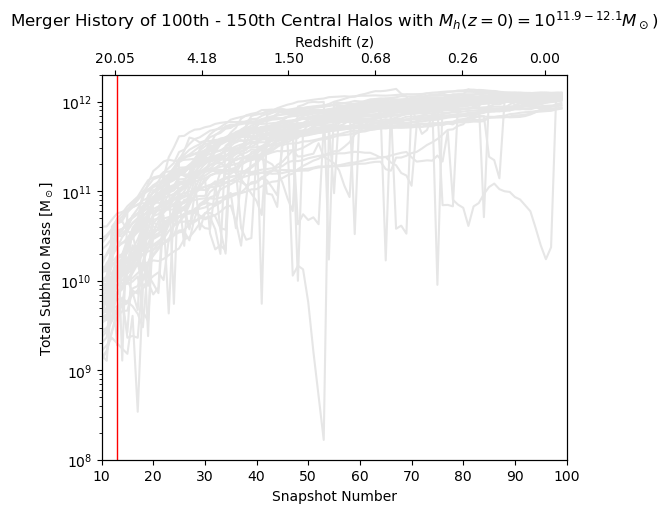

In [16]:
snap = 13

m = mass_logmsun[central_subhalo_ids]
w = np.where((m>logm-binSize/2.) & (m<=logm+binSize/2.))
ids = central_subhalo_ids[w]
len(mass_logmsun[w])

fig = plt.figure(figsize=(6,5)) # 上軸のラベルが見やすくなるよう縦幅を少し広げました
ax = fig.add_subplot(111)

fields = ['SubhaloMass','SubfindID','SnapNum']
start = 99
num = 50
for i in range(start, start+num):
    tree = il.sublink.loadTree(basePath, 99, ids[i], fields=fields, onlyMPB=True)
    mass_msun_tree = tree['SubhaloMass'] * 1e10 / 0.6774
    ax.plot(tree['SnapNum'], mass_msun_tree, '-', label='sub %d' % central_subhalo_ids[i],c='0.9')
    
ax.set_yscale('log')
ax.set_xlabel('Snapshot Number')
ax.set_ylabel('Total Subhalo Mass [M$_\odot$]')
#ax.legend()

# グラフのX軸の範囲を固定（これを行わないと上下の軸がズレる原因になります）
ax.set_xlim(tree['SnapNum'].min()-5, tree['SnapNum'].max()+5)

# --- 修正版：ここから二重のX軸を追加する処理 ---
ax2 = ax.twiny()

# グラフの表示範囲（Snapshotの最小値と最大値）を取得
xmin, xmax = ax.get_xlim()
ax2.set_xlim(xmin, xmax)

# 【修正ポイント】目盛りを20刻みの綺麗な数値だけに固定する（データの端は追加しない）
top_ticks = np.array([0,20,40,60,80,99])

# もしグラフの左端（xmin）が0より大きい場合、範囲外の目盛りを排除する
top_ticks = top_ticks[top_ticks >= xmin]

ax2.set_xticks(top_ticks)

# 対応するRedshiftラベルを作成
top_labels = ['%.2f' % snap_to_z[int(snap)] for snap in top_ticks]
ax2.set_xticklabels(top_labels)
ax.set_title('Merger History of %dth - %dth Central Halos with $M_h(z=0)=10^{%.1f-%.1f}M_\odot)$'%(start+1,start+num+1,logm-binSize/2.,logm+binSize/2.))
ax2.set_xlabel('Redshift (z)');
ax.set_xlim([10.0,100.0])
ax.set_ylim([1e+8,2e+12]);
ax.axvline(x=13, color='red', linestyle='-', linewidth=1);
# --------------------------------------------

In [17]:
import time
z = snap_to_z[snap]
binSize = 0.2

logmass = np.full(len(ids), np.nan)

st = time.time()
for i in range (len(ids)):
    tree = il.sublink.loadTree(basePath, 99, ids[i], fields=fields, onlyMPB=True)
    w = np.where(tree['SnapNum']==snap)[0]
    if len(w)>0:
        logmass[i] = np.log10(tree['SubhaloMass'][w][0] * 1e10 / 0.6774)
logmass = logmass[~np.isnan(logmass)]
en = time.time()

t = en-st
print(t)
print(t/60)
print(len(central_subhalo_ids)/len(ids))
t*len(central_subhalo_ids)/len(ids)/60/60

32.37334871292114
0.5395558118820191
3745.312227074236


33.680082990511536

908
bin size = 0.186 dex
1.0


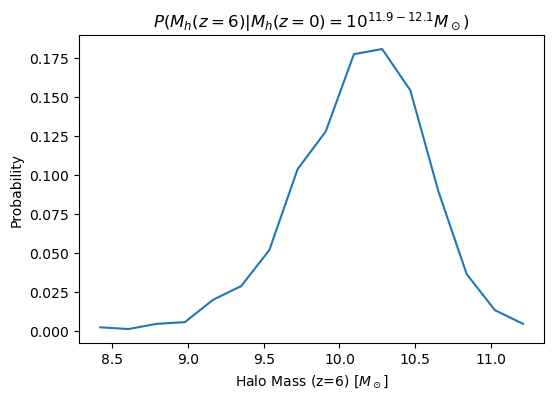

In [47]:
print(len(logmass))
hist, bins = np.histogram(logmass, bins=16, density = False) 
hist = hist / len(logmass)
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot((bins[1:]+bins[:-1])/2., hist, '-')
#ax.set_yscale('log')
#ax.set_xlim([7.0,12.5])
ax.set_title('$P(M_h(z=6)|M_h(z=0)=10^{%.1f-%.1f}M_\odot)$'%(logm-binSize/2.,logm+binSize/2.))
ax.set_xlabel('Halo Mass (z=6) [$M_\odot$]')
ax.set_ylabel('Probability');
print(f"bin size = {(bins[1:]-bins[:-1])[0]:.3f} dex")
print(np.sum(hist))

In [43]:
mass_logmsun = np.log10(mass_msun)
print("z=0")
print("Number of all subhalos ->",len(mass_msun))
print("Number of central subhalos:")
print("all mass range ->",len(central_subhalo_ids))
m = mass_logmsun[central_subhalo_ids]
m = m[(m>logm-binSize/2.) & (m<=logm+binSize/2.)]
print(f"log(Mh)={logm:.2f}  -> {len(m)} (within {binSize} dex)")
pa = len(m)/len(central_subhalo_ids)
print(f'Probability of log(Mh[Mo])={logm-binSize/2.:.1f}-{logm+binSize/2.:.1f}')
print(f'-> {len(m)}/{len(central_subhalo_ids)}={pa:.2e}')

z=0
Number of all subhalos -> 4371211
Number of central subhalos:
all mass range -> 3430706
log(Mh)=12.00  -> 916 (within 0.2 dex)
Probability of log(Mh[Mo])=11.9-12.1
-> 916/3430706=2.67e-04


In [44]:
print(f"z={snap_to_z[snap]}")
subhalos_highz = il.groupcat.loadSubhalos(basePath, snap, fields=fields_sub)
## Total mass of all member particle/cells which are bound to this Subhalo, of all types.
mass_msun_highz = subhalos_highz['SubhaloMass'] * 1e10 / 0.6774  # Total mass of subhalo
mass_logmsun_highz = np.log10(mass_msun_highz)

GroupFirstSub_highz = il.groupcat.loadHalos(basePath,snap,fields=['GroupFirstSub'])
w = np.where(GroupFirstSub_highz >= 0) # value of -1 indicates no subhalo in this group
central_subhalo_ids_highz = GroupFirstSub_highz[w]

z=6.0107573988449


Number of all subhalos -> 5519031
Number of central subhalos:
all mass range -> 5094717
bin size = 0.186 dex
0.676433058008914


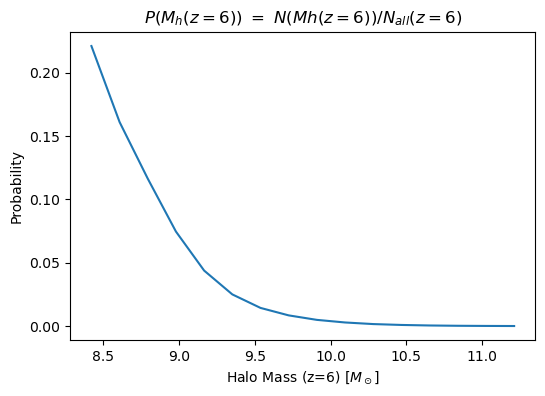

In [48]:
print("Number of all subhalos ->",len(mass_msun_highz))
print("Number of central subhalos:")
print("all mass range ->",len(central_subhalo_ids_highz))

m = mass_logmsun_highz[central_subhalo_ids_highz]
pb = np.zeros(len(hist))
for i in range(len(hist)):
    pb[i] = len(m[(m>=bins[i]) & (m<bins[i+1])])
pb /= len(central_subhalo_ids_highz)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot((bins[1:]+bins[:-1])/2., pb, '-')
#ax.set_yscale('log')
#ax.set_xlim([7.0,12.5])
ax.set_title('$P(M_h(z=6))\ =\ N(Mh(z=6))/N_{all}(z=6)$')
ax.set_xlabel('Halo Mass (z=6) [$M_\odot$]')
ax.set_ylabel('Probability');
print(f"bin size = {(bins[1:]-bins[:-1])[0]:.3f} dex")
print(np.sum(pb))

bin size = 0.186 dex
0.23301747956637658


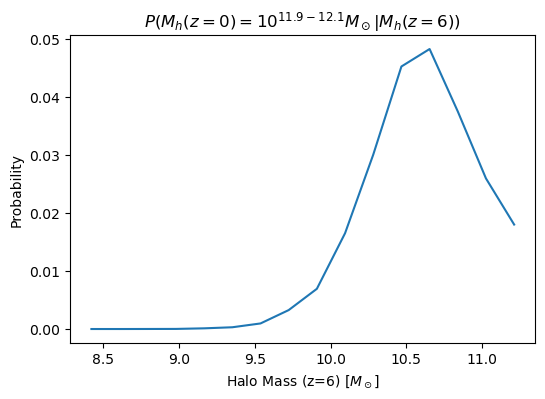

In [83]:
y=pa*hist/pb
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot((bins[1:]+bins[:-1])/2., y, '-')
#ax.set_yscale('log')
#ax.set_xlim([7.0,12.5])
ax.set_title('$P(M_h(z=0)=10^{%.1f-%.1f}M_\odot|M_h(z=6))$'%(logm-binSize/2.,logm+binSize/2.))
ax.set_xlabel('Halo Mass (z=6) [$M_\odot$]')
ax.set_ylabel('Probability');
print(f"bin size = {(bins[1:]-bins[:-1])[0]:.3f} dex")
print(np.sum(y))

In [52]:
print(bins)
print((bins[1:]+bins[:-1])/2.)

[ 8.32755015  8.51363819  8.69972624  8.88581428  9.07190232  9.25799036
  9.4440784   9.63016644  9.81625448 10.00234252 10.18843056 10.3745186
 10.56060664 10.74669468 10.93278272 11.11887076 11.3049588 ]
[ 8.42059417  8.60668221  8.79277026  8.9788583   9.16494634  9.35103438
  9.53712242  9.72321046  9.9092985  10.09538654 10.28147458 10.46756262
 10.65365066 10.8397387  11.02582674 11.21191478]


In [65]:
tree_dir = os.path.join(os.path.dirname(basePath.rstrip('/')), 'postprocessing/trees/SubLink/')
for i in range(0, 20):
    tree_file = os.path.join(tree_dir, f'tree_extended.{i}.hdf5')
print(descendant_ids)

[                -1 140000000000000000 140000000000000001 ...
 140028792500000076 140028792500000077 140028792500000078]


In [68]:
import os
import h5py
ii = 12
m = mass_logmsun_highz[central_subhalo_ids_highz]
w = np.where((m>=bins[ii]) & (m<bins[ii+1]))
start_ids = central_subhalo_ids_highz[w]
print(f"Snapshot {snap_start} で条件に合うハローの数: {len(start_ids)} 個")
snap_start = 13
snap_end = 99

log_mass_99 = []

fields = ['SnapNum', 'SubhaloMass']

for s_id in start_ids:
    # onlyMDB=True により、指定したハローの「未来への一本道」だけをロード
    tree = il.sublink.loadTree(basePath, snap_start, s_id, fields=fields, onlyMDB=True)
    
    if tree is not None:
        # 未来の終着点（Snapshot 99）のデータをピンポイントで探す
        w = np.where(tree['SnapNum'] == snap_end)[0]
        if len(w) > 0:
            mass_99 = tree['SubhaloMass'][w[0]] * 1e10 / 0.6774
            if mass_99 > 0:
                log_mass_99.append(np.log10(mass_99))

log_mass_99 = np.array(log_mass_99)
print(f"z=0 まで生き残ったハローの数: {len(log_mass_99)} 個")

Snapshot 13 で条件に合うハローの数: 2516 個
z=0 まで生き残ったハローの数: 2516 個


2516
bin size = 0.204 dex
0.9999999999999999


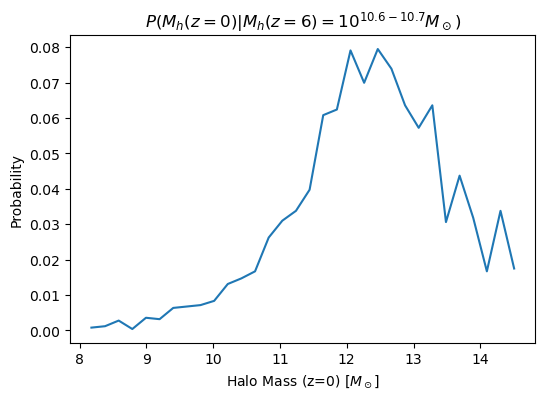

In [81]:
print(len(log_mass_99))
hist_99, bins_99 = np.histogram(log_mass_99, bins=32, density = False) 
hist_99 = hist_99 / len(log_mass_99)
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot((bins_99[1:]+bins_99[:-1])/2., hist_99, '-')
#ax.set_yscale('log')
#ax.set_xlim([7.0,12.5])
ax.set_title('$P(M_h(z=0)|M_h(z=6)=10^{%.1f-%.1f}M_\odot)$'%(bins[ii],bins[ii+1]))
ax.set_xlabel('Halo Mass (z=0) [$M_\odot$]')
ax.set_ylabel('Probability');
print(f"bin size = {(bins_99[1:]-bins_99[:-1])[0]:.3f} dex")
print(np.sum(hist_99))

In [61]:
with h5py.File(tree_file, 'r') as f:
    print("ファイル内のデータセット一覧:")
    print(list(f.keys()))

ファイル内のデータセット一覧:
['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRa